### Model 1 implementation using no libraries ###

In [1]:
import numpy as np
import math 

# Data loading functions
def load_csv(filepath):
    """Load CSV file using numpy"""
    try:
        data = np.genfromtxt(filepath, delimiter=',', dtype=str, skip_header=1, encoding='utf-8')
        with open(filepath, 'r', encoding='utf-8') as f:
            import csv
            reader = csv.reader(f)
            headers = next(reader)
        return headers, data
    except Exception as e:
        print(f"Error loading file: {e}")
        return [], []

In [2]:
def preprocess_data(data, headers):
    """
    Prepares the data for our decision tree model. It converts the data to numbers
    and creates the feature matrix (X) and the target vector (y).
    """
    # Convert data to a numerical format, turning any non-numeric values into 0.0
    numeric_data = []
    for row in data:
        numeric_row = []
        for val in row:
            try:
                # Try to convert each value to a float
                numeric_row.append(float(val))
            except (ValueError, TypeError):
                # If it fails, just use 0.0
                numeric_row.append(0.0)
        numeric_data.append(numeric_row)
    
    data_array = np.array(numeric_data)
    
    # --- This is the key change ---
    # We now define our target variable 'y' as the claim frequency.
    # Claim Frequency = Number of Claims / Exposure Period
    
    claim_nb_col = data_array[:, 1]  # The 'ClaimNb' column
    exposure_col = data_array[:, 2]  # The 'Exposure' column
    
    # To avoid dividing by zero, we'll create a default 'y' array of zeros.
    # We only calculate the frequency where exposure is greater than zero.
    y = np.zeros_like(claim_nb_col)
    
    # Create a mask for rows where exposure is positive to avoid division by zero
    positive_exposure_mask = exposure_col > 0
    
    # Calculate claim frequency only for valid entries
    y[positive_exposure_mask] = claim_nb_col[positive_exposure_mask] / exposure_col[positive_exposure_mask]
    
    # All other columns (except ID, ClaimNb, and Exposure) will be our features.
    # We exclude column 0 ('IDpol') as well.
    feature_indices = [i for i in range(data_array.shape[1]) if i not in [0, 1, 2]]
    X = data_array[:, feature_indices]
    
    return X, y

In [3]:
class FastDecisionTree:
    """
    A simplified and commented Decision Tree for regression tasks.
    It's designed to be easier to understand than library implementations.
    """
    def __init__(self, max_depth=8, min_samples_split=50, max_features='sqrt', random_state=42):
        # --- Tree Settings ---
        # These are the rules that tell our tree when to stop growing.
        
        # How deep can the tree go?
        self.max_depth = max_depth
        # What's the minimum number of samples a node needs to have before it can be split?
        self.min_samples_split = min_samples_split
        # When looking for the best split, how many features should we check?
        # 'sqrt' means we'll check the square root of the total number of features.
        self.max_features = max_features
        
        # This ensures that our "random" choices are the same every time we run the code.
        self.random_state = random_state
        self.root = None

    def fit(self, X, y):
        """
        This is where the tree learns from the data.
        It starts the recursive process of building the tree.
        """
        np.random.seed(self.random_state)
        self.n_features = X.shape[1]
        
        # Adjust the number of features to consider at each split
        if self.max_features == 'sqrt':
            self.max_features_ = int(np.sqrt(self.n_features))
        elif self.max_features == 'log2':
            self.max_features_ = int(np.log2(self.n_features)) + 1
        else:
            self.max_features_ = self.max_features
            
        # Start building the tree from the top (depth = 0)
        self.root = self._build_tree(X, y, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        """
        The heart of the algorithm: a recursive function that builds the tree, node by node.
        A "node" is just a point in the tree where we ask a question about the data.
        """
        n_samples = X.shape[0]
        
        # --- When should we stop splitting and create a leaf? ---
        # 1. If we've reached the maximum allowed depth.
        # 2. If we don't have enough samples to make a meaningful split.
        # 3. If all the samples in the current node have the same target value (no reason to split further).
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            np.var(y) < 1e-8): # A very small variance means all y values are nearly the same.
            
            # If we stop, we create a "leaf node" which gives a final prediction.
            return self._make_leaf_node(y)
        
        # Find the best feature and threshold to split the data on.
        best_feature, best_threshold, best_improvement = self._find_best_split(X, y)
        
        # If we couldn't find a split that improves the model, stop here too.
        if best_feature is None:
            return self._make_leaf_node(y)
        
        # --- Split the Data ---
        # Divide the data into two groups based on the best question we found.
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        # Make sure both new groups have at least a few samples.
        if np.sum(left_mask) < 5 or np.sum(right_mask) < 5:
            return self._make_leaf_node(y)
            
        # --- Recursion ---
        # Now, we do the same thing for the left and right groups. This is what makes it a "tree".
        left_node = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_node = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        # Return a dictionary that represents this "decision node".
        return {
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_node,
            'right': right_node,
            'leaf': False # This is a decision node, not a leaf.
        }

    def _find_best_split(self, X, y):
        """
        Looks for the best question to ask to split the data.
        A "good" split is one that makes the two resulting groups as pure as possible.
        For regression, this means minimizing the variance in each group.
        """
        best_variance_reduction = -1
        best_feature, best_threshold = None, None
        current_variance = np.var(y)
        
        # Randomly select a subset of features to check (this makes the model faster and more robust).
        feature_indices = np.random.choice(self.n_features, self.max_features_, replace=False)
        
        for feature_idx in feature_indices:
            feature_values = X[:, feature_idx]
            # Get potential split points for the current feature.
            thresholds = np.unique(feature_values)
            if len(thresholds) > 10: # If too many unique values, check a sample of them.
                thresholds = np.percentile(feature_values, np.arange(10, 100, 10))

            for threshold in thresholds:
                # Split the data based on the threshold
                left_mask = feature_values <= threshold
                y_left, y_right = y[left_mask], y[~left_mask]

                # Ensure the split creates two non-empty groups
                if len(y_left) < 2 or len(y_right) < 2:
                    continue

                # Calculate the weighted variance of the two new groups
                var_left, var_right = np.var(y_left), np.var(y_right)
                p_left = len(y_left) / len(y)
                weighted_variance = p_left * var_left + (1 - p_left) * var_right
                
                # How much did this split reduce the overall variance?
                variance_reduction = current_variance - weighted_variance

                # If this split is the best one we've seen so far, save it.
                if variance_reduction > best_variance_reduction:
                    best_variance_reduction = variance_reduction
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_variance_reduction
    
    def _make_leaf_node(self, y):
        """Creates a leaf node, which is the endpoint of a branch in the tree."""
        # The prediction for this leaf will simply be the average of all target values
        # that ended up in this leaf.
        prediction = np.mean(y) if len(y) > 0 else 0
        return {'value': prediction, 'leaf': True}

    def predict(self, X):
        """Makes predictions for a whole dataset by running each row through the tree."""
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self, x, node=None):
        """Navigates a single data point (a row) through the tree to get a prediction."""
        if node is None:
            node = self.root
        
        # If we're at a leaf node, we have our final prediction.
        if node['leaf']:
            return node['value']
        
        # If we're at a decision node, ask the question and go left or right.
        if x[node['feature']] <= node['threshold']:
            return self._predict_single(x, node['left'])
        else:
            return self._predict_single(x, node['right'])

In [4]:
# Evaluation functions for REGRESSION 
def train_test_split_numpy(X, y, test_size=0.2, random_state=42):
    """Train-test split using only numpy"""
    np.random.seed(random_state)
    n_samples = X.shape[0]
    n_test = int(n_samples * test_size)
    
    indices = np.random.permutation(n_samples)
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]
    
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

# REGRESSION metrics 
def mean_squared_error_numpy(y_true, y_pred):
    """MSE using only numpy"""
    return np.mean((y_true - y_pred) ** 2)

def r2_score_numpy(y_true, y_pred):
    """R² score using only numpy"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

def mean_absolute_error_numpy(y_true, y_pred):
    """MAE using only numpy"""
    return np.mean(np.abs(y_true - y_pred))

In [5]:
# Main execution
if __name__ == "__main__":
    # Load your data
    print("Loading data...")
    headers, data = load_csv('Data/claims_train_with_freq_filtered.csv')
    if len(data) == 0:
        print("Failed to load data")
        exit()
    
    print(f"Loaded {len(data)} samples with {len(headers)} columns")
    print("Headers:", headers)
    
    # Preprocess data for regression
    print("Preprocessing data for regression...")
    X, y = preprocess_data(data, headers)
    
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"Risk scores - Min: {y.min():.4f}, Max: {y.max():.4f}, Mean: {y.mean():.4f}")
    
    # Show risk distribution
    print("Risk distribution:")
    for threshold in [0.1, 0.2, 0.3, 0.5]:
        count = np.sum(y >= threshold)
        print(f"  Risk >= {threshold}: {count} samples ({count/len(y)*100:.1f}%)")
    
    # Split data
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split_numpy(X, y, test_size=0.2)
    
    print(f"Training set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Train regression model
    print("Training FastDecisionTree for regression...")
    model = FastDecisionTree(max_depth=6, min_samples_split=50, max_features='sqrt')
    model.fit(X_train, y_train)
    print("Training completed!")
    
    # Predictions
    print("Making predictions...")
    y_pred = model.predict(X_test)
    
    # Evaluation for regression
    mse = mean_squared_error_numpy(y_test, y_pred)
    r2 = r2_score_numpy(y_test, y_pred)
    mae = mean_absolute_error_numpy(y_test, y_pred)
    
    print(f"\nRegression Results:")
    print(f"MSE: {mse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.6f}")
    print(f"Predicted risk range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
    print(f"Actual risk range: [{y_test.min():.4f}, {y_test.max():.4f}]")

Loading data...
Loaded 541416 samples with 13 columns
Headers: ['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region', 'ClaimFrequency']
Preprocessing data for regression...
Features shape: (541416, 10)
Target shape: (541416,)
Risk scores - Min: 0.0000, Max: 732.0000, Mean: 0.2616
Risk distribution:
  Risk >= 0.1: 27170 samples (5.0%)
  Risk >= 0.2: 27170 samples (5.0%)
  Risk >= 0.3: 27170 samples (5.0%)
  Risk >= 0.5: 27170 samples (5.0%)
Splitting data...
Training set: (433133, 10)
Test set: (108283, 10)
Training FastDecisionTree for regression...
Training completed!
Making predictions...

Regression Results:
MSE: 11.723273
R² Score: 0.2126
MAE: 0.238121
Predicted risk range: [0.0000, 42.0920]
Actual risk range: [0.0000, 366.0000]


### Decision boundaries on the decision tree



Generating Decision Boundary Visualization...
Visualization model trained. Now plotting boundaries...


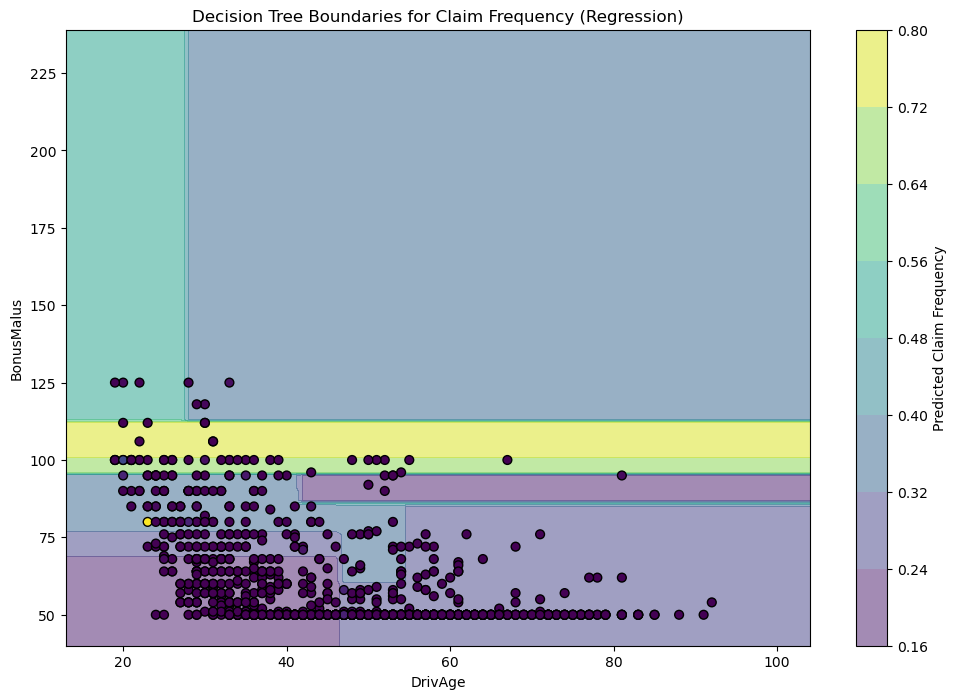

In [6]:
# --- Code Snippet for Visualizing Decision Boundaries ---
# This should be added to a new cell at the end of your M1.ipynb notebook

import matplotlib.pyplot as plt

print("\nGenerating Decision Boundary Visualization...")

# 1. Select two features for visualization
# We choose DrivAge (index 3) and BonusMalus (index 4) from our preprocessed X matrix.
feature_indices_vis = [3, 4]
feature_names_vis = ['DrivAge', 'BonusMalus']

# Create a new, 2D dataset for training the visualization model
X_vis = X_train[:, feature_indices_vis]
y_vis = y_train

# 2. Train a new, simpler Decision Tree on only these two features
# A shallower depth makes the boundaries easier to interpret.
model_vis = FastDecisionTree(max_depth=4, min_samples_split=100)
model_vis.fit(X_vis, y_vis)

print("Visualization model trained. Now plotting boundaries...")

# 3. Create a mesh grid to plot the decision surface
h = 1.0  # Step size in the mesh
x_min, x_max = X_vis[:, 0].min() - 5, X_vis[:, 0].max() + 5
y_min, y_max = X_vis[:, 1].min() - 10, X_vis[:, 1].max() + 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 4. Predict the value for each point in the mesh grid
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot the results
plt.figure(figsize=(12, 8))
# Plot the decision surface with contourf
contour = plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')

# Overlay the actual data points from a sample of the training set
# We use a sample to avoid over-plotting
sample_indices = np.random.choice(X_vis.shape[0], 1000, replace=False)
scatter = plt.scatter(X_vis[sample_indices, 0], X_vis[sample_indices, 1], 
                      c=y_vis[sample_indices], cmap='viridis', edgecolor='k', s=40)

# Add labels, title, and a color bar to interpret the predictions
plt.xlabel(feature_names_vis[0])
plt.ylabel(feature_names_vis[1])
plt.title('Decision Tree Boundaries for Claim Frequency (Regression)')
plt.colorbar(contour, label='Predicted Claim Frequency')
plt.show()